In [1]:
# ============================================================
# PART 1
# Automatic Dataset Detection
# Bruno et al. ADL Dataset
# ============================================================

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# Install Required Libraries
# ============================================================

!pip -q install scipy openpyxl tqdm

# ============================================================
# Import Libraries
# ============================================================

import os
import glob
import time
import numpy as np
import pandas as pd

from tqdm import tqdm

from scipy.signal import medfilt
from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import entropy
from scipy.fft import fft

# ============================================================
# USER PARAMETERS
# ============================================================

# Parent folder containing all activity folders

PARENT_FOLDER = "/content/drive/MyDrive/Colab Notebooks/HAR/HMP_Dataset"

# Output folder

OUTPUT_FOLDER = "/content/drive/MyDrive/Colab Notebooks/HAR/HMP_output"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ------------------------------------------------------------
# Window Parameters
# ------------------------------------------------------------

SAMPLING_RATE = 32          # Change if required

WINDOW_SECONDS = 1

WINDOW_SIZE = SAMPLING_RATE * WINDOW_SECONDS

OVERLAP = 0.5

STEP_SIZE = int(WINDOW_SIZE * (1-OVERLAP))

# ------------------------------------------------------------
# Accelerometer Conversion
# ------------------------------------------------------------

ACC_MIN = -14.709

ACC_MAX = 14.709

# ============================================================
# Detect Activity Folders
# ============================================================

print("="*60)
print("Scanning Dataset...")
print("="*60)

activity_folders = []

for folder in sorted(os.listdir(PARENT_FOLDER)):

    full_path = os.path.join(PARENT_FOLDER, folder)

    if not os.path.isdir(full_path):
        continue

    # Ignore MODEL folders
    if folder.endswith("_MODEL"):
        continue

    activity_folders.append(full_path)

print()

print("Activities Detected")

for i,f in enumerate(activity_folders):

    print(f"{i+1:02d}. {os.path.basename(f)}")

print()

print("Total Activities :",len(activity_folders))

# ============================================================
# Count Files
# ============================================================

total_files = 0

activity_file_count = {}

print()

print("="*60)
print("Counting Files")
print("="*60)

for folder in activity_folders:

    txt_files = glob.glob(os.path.join(folder,"*.txt"))

    activity = os.path.basename(folder)

    activity_file_count[activity] = len(txt_files)

    total_files += len(txt_files)

for k,v in activity_file_count.items():

    print(f"{k:25s} {v:5d}")

print()

print("="*60)

print("Total Files :",total_files)

print("="*60)

# ============================================================
# Prepare Dataset Information
# ============================================================

dataset_info = []

for folder in activity_folders:

    activity = os.path.basename(folder)

    txt_files = sorted(glob.glob(os.path.join(folder,"*.txt")))

    for file in txt_files:

        dataset_info.append({

            "Activity":activity,

            "File":file

        })

dataset_info = pd.DataFrame(dataset_info)

print()

print(dataset_info.head())

print()

print("Dataset Shape :",dataset_info.shape)

# ============================================================
# Save Dataset Information
# ============================================================

dataset_info.to_csv(

    os.path.join(

        OUTPUT_FOLDER,

        "Dataset_File_List.csv"

    ),

    index=False

)

print()

print("Dataset file list saved.")

print()

print("="*60)
print("PART 1 COMPLETED")
print("="*60)

Mounted at /content/drive
Scanning Dataset...

Activities Detected
01. Brush_teeth
02. Climb_stairs
03. Comb_hair
04. Descend_stairs
05. Drink_glass
06. Eat_meat
07. Eat_soup
08. Getup_bed
09. Liedown_bed
10. Pour_water
11. Sitdown_chair
12. Standup_chair
13. Use_telephone
14. Walk

Total Activities : 14

Counting Files
Brush_teeth                  12
Climb_stairs                102
Comb_hair                    31
Descend_stairs               42
Drink_glass                 100
Eat_meat                      5
Eat_soup                      3
Getup_bed                   101
Liedown_bed                  28
Pour_water                  100
Sitdown_chair               100
Standup_chair               102
Use_telephone                13
Walk                        100

Total Files : 839

      Activity                                               File
0  Brush_teeth  /content/drive/MyDrive/Colab Notebooks/HAR/HMP...
1  Brush_teeth  /content/drive/MyDrive/Colab Notebooks/HAR/HMP...
2  Brush_tee

PART 2 : Reading Accelerometer Files


Processing Files: 100%|██████████| 839/839 [04:38<00:00,  3.01it/s]



Reading Completed
Total Recordings : 839
Processing Time  : 278.36 seconds

Example Recording
Activity : Brush_teeth
Trial    : Accelerometer-2011-04-11-13-28-18-brush_teeth-f1.txt
Samples  : 2167

First 10 X values
[-4.436 -4.436 -4.436 -4.436 -4.436 -4.903 -4.436 -4.436 -4.436 -4.436]

First 10 Y values
[8.172 8.172 9.573 9.573 9.573 9.106 9.106 8.639 9.106 9.106]

First 10 Z values
[1.634 1.634 1.634 1.634 1.167 1.167 1.167 1.167 1.167 1.167]

Signal Statistics
Minimum Samples : 125
Maximum Samples : 9318
Average Samples : 532.22

Files Per Activity
          Activity  Files
0      Brush_teeth     12
1     Climb_stairs    102
2        Comb_hair     31
3   Descend_stairs     42
4      Drink_glass    100
5         Eat_meat      5
6         Eat_soup      3
7        Getup_bed    101
8      Liedown_bed     28
9       Pour_water    100
10   Sitdown_chair    100
11   Standup_chair    102
12   Use_telephone     13
13            Walk    100


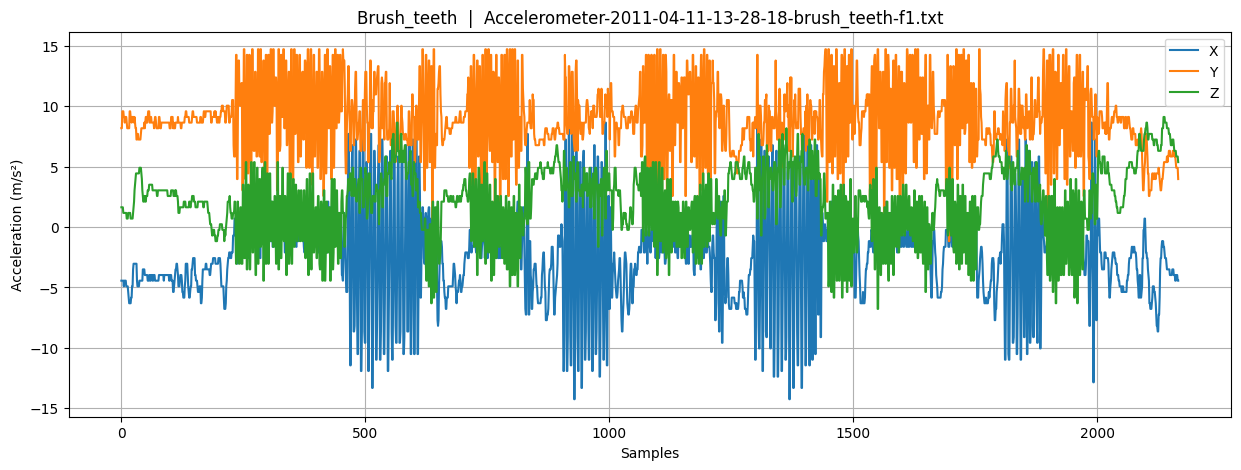


PART 2 COMPLETED


In [2]:
# ============================================================
# PART 2
# Read All Accelerometer Files
# Convert to Real Acceleration
# Median Filtering
# ============================================================

print("="*70)
print("PART 2 : Reading Accelerometer Files")
print("="*70)

from scipy.signal import medfilt

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

MEDIAN_FILTER_SIZE = 3

# ------------------------------------------------------------
# Store all processed recordings
# ------------------------------------------------------------

all_recordings = []

# ------------------------------------------------------------
# Read every activity
# ------------------------------------------------------------

start_time = time.time()

for idx, row in tqdm(dataset_info.iterrows(),
                     total=len(dataset_info),
                     desc="Processing Files"):

    activity = row["Activity"]
    filename = row["File"]

    try:

        # ----------------------------------------------------
        # Read TXT file
        # ----------------------------------------------------

        data = pd.read_csv(
            filename,
            sep=r"\s+",
            header=None,
            names=["X","Y","Z"]
        )

        # Skip invalid files
        if len(data) == 0:
            continue

        # ----------------------------------------------------
        # Convert Integer Values
        # MATLAB:
        # -14.709 + (value/63)*(2*14.709)
        # ----------------------------------------------------

        X = ACC_MIN + (data["X"]/63.0)*(2*14.709)
        Y = ACC_MIN + (data["Y"]/63.0)*(2*14.709)
        Z = ACC_MIN + (data["Z"]/63.0)*(2*14.709)

        # ----------------------------------------------------
        # Median Filtering
        # ----------------------------------------------------

        X = medfilt(X, kernel_size=MEDIAN_FILTER_SIZE)
        Y = medfilt(Y, kernel_size=MEDIAN_FILTER_SIZE)
        Z = medfilt(Z, kernel_size=MEDIAN_FILTER_SIZE)

        # ----------------------------------------------------
        # Store recording
        # ----------------------------------------------------

        recording = {
            "activity": activity,
            "trial": os.path.basename(filename),
            "samples": len(X),
            "X": np.array(X),
            "Y": np.array(Y),
            "Z": np.array(Z)
        }

        all_recordings.append(recording)

    except Exception as e:

        print()
        print("Error:", filename)
        print(e)

elapsed = time.time() - start_time

print()
print("="*70)
print("Reading Completed")
print("="*70)

print("Total Recordings :", len(all_recordings))
print("Processing Time  :", round(elapsed,2), "seconds")

# ------------------------------------------------------------
# Display sample recording
# ------------------------------------------------------------

print()
print("="*70)
print("Example Recording")
print("="*70)

sample = all_recordings[0]

print("Activity :", sample["activity"])
print("Trial    :", sample["trial"])
print("Samples  :", sample["samples"])

print()

print("First 10 X values")

print(np.round(sample["X"][:10],3))

print()

print("First 10 Y values")

print(np.round(sample["Y"][:10],3))

print()

print("First 10 Z values")

print(np.round(sample["Z"][:10],3))

# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

lengths = [rec["samples"] for rec in all_recordings]

print()
print("="*70)
print("Signal Statistics")
print("="*70)

print("Minimum Samples :", np.min(lengths))
print("Maximum Samples :", np.max(lengths))
print("Average Samples :", round(np.mean(lengths),2))

# ------------------------------------------------------------
# Activity Distribution
# ------------------------------------------------------------

activity_summary = {}

for rec in all_recordings:

    activity = rec["activity"]

    if activity not in activity_summary:
        activity_summary[activity] = 0

    activity_summary[activity] += 1

print()
print("="*70)
print("Files Per Activity")
print("="*70)

summary_df = pd.DataFrame(
    activity_summary.items(),
    columns=["Activity","Files"]
)

summary_df = summary_df.sort_values("Activity")

print(summary_df)

summary_df.to_csv(
    os.path.join(
        OUTPUT_FOLDER,
        "Activity_File_Summary.csv"
    ),
    index=False
)

# ------------------------------------------------------------
# Optional Visualization
# ------------------------------------------------------------

import matplotlib.pyplot as plt

example = all_recordings[0]

plt.figure(figsize=(15,5))

plt.plot(example["X"],label="X")
plt.plot(example["Y"],label="Y")
plt.plot(example["Z"],label="Z")

plt.title(example["activity"] + "  |  " + example["trial"])

plt.xlabel("Samples")

plt.ylabel("Acceleration (m/s²)")

plt.legend()

plt.grid(True)

plt.show()

print()
print("="*70)
print("PART 2 COMPLETED")
print("="*70)

PART 3 : Sliding Window Segmentation


Creating Windows: 100%|██████████| 839/839 [00:00<00:00, 4735.46it/s]


Window Generation Completed
Total Windows : 26663

Example Window
------------------------------
Window ID      : 1
Activity       : Brush_teeth
Trial          : Accelerometer-2011-04-11-13-28-18-brush_teeth-f1.txt
Window Number  : 1

Start Sample : 0
End Sample   : 31

Window Shape
X : (32,)
Y : (32,)
Z : (32,)

First 10 X values
[-4.436 -4.436 -4.436 -4.436 -4.436 -4.903 -4.436 -4.436 -4.436 -4.436]

First 10 Y values
[8.172 8.172 9.573 9.573 9.573 9.106 9.106 8.639 9.106 9.106]

First 10 Z values
[1.634 1.634 1.634 1.634 1.167 1.167 1.167 1.167 1.167 1.167]



Windows Per Activity
          Activity  Windows
0      Brush_teeth     1846
1     Climb_stairs     2363
2        Comb_hair     1424
3   Descend_stairs      898
4      Drink_glass     2524
5         Eat_meat     1945
6         Eat_soup      413
7        Getup_bed     2715
8      Liedown_bed      672
9       Pour_water     2461
10   Sitdown_chair     1415
11   Standup_chair     1436
12   Use_telephone      932
13            Walk     5619

Window Length Verification
Minimum : 32
Maximum : 32
Average : 32.0


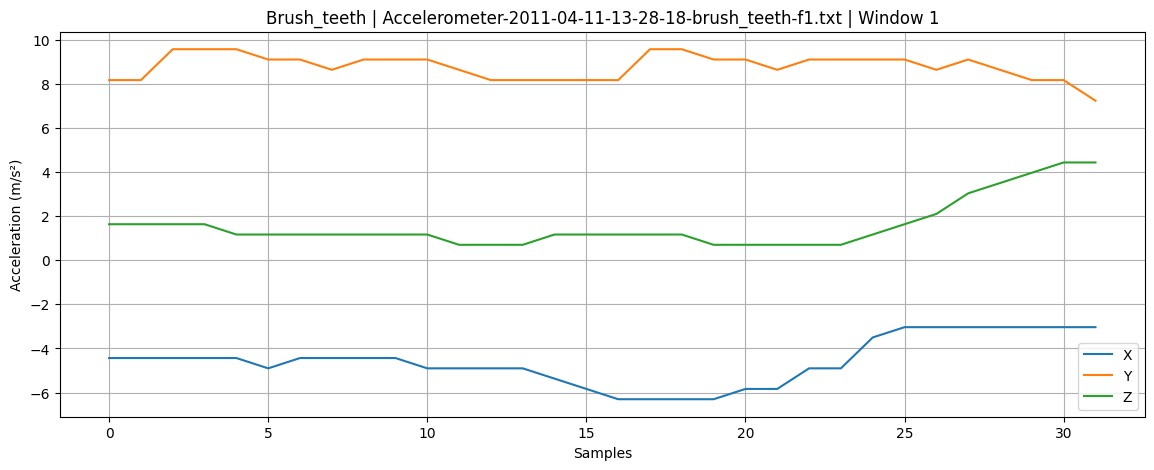


PART 3 COMPLETED


In [3]:
# ============================================================
# PART 3
# Sliding Window Segmentation
# ============================================================

print("="*70)
print("PART 3 : Sliding Window Segmentation")
print("="*70)

windowed_data = []

window_counter = 0

# ------------------------------------------------------------
# Process each recording
# ------------------------------------------------------------

for recording in tqdm(all_recordings, desc="Creating Windows"):

    activity = recording["activity"]
    trial = recording["trial"]

    X = recording["X"]
    Y = recording["Y"]
    Z = recording["Z"]

    total_samples = len(X)

    # Skip recordings shorter than one window
    if total_samples < WINDOW_SIZE:
        continue

    local_window = 1

    # Sliding window
    for start in range(0, total_samples - WINDOW_SIZE + 1, STEP_SIZE):

        end = start + WINDOW_SIZE

        x_window = X[start:end]
        y_window = Y[start:end]
        z_window = Z[start:end]

        window_counter += 1

        windowed_data.append({

            "Window_ID": window_counter,

            "Activity": activity,

            "Trial": trial,

            "Trial_Window": local_window,

            "Start_Sample": start,

            "End_Sample": end-1,

            "X": x_window,

            "Y": y_window,

            "Z": z_window

        })

        local_window += 1

print()

print("="*70)
print("Window Generation Completed")
print("="*70)

print("Total Windows :", len(windowed_data))

# ------------------------------------------------------------
# Display one example window
# ------------------------------------------------------------

example = windowed_data[0]

print()

print("Example Window")

print("------------------------------")

print("Window ID      :", example["Window_ID"])
print("Activity       :", example["Activity"])
print("Trial          :", example["Trial"])
print("Window Number  :", example["Trial_Window"])

print()

print("Start Sample :", example["Start_Sample"])
print("End Sample   :", example["End_Sample"])

print()

print("Window Shape")

print("X :", example["X"].shape)
print("Y :", example["Y"].shape)
print("Z :", example["Z"].shape)

print()

print("First 10 X values")

print(np.round(example["X"][:10],3))

print()

print("First 10 Y values")

print(np.round(example["Y"][:10],3))

print()

print("First 10 Z values")

print(np.round(example["Z"][:10],3))

# ------------------------------------------------------------
# Activity-wise Window Statistics
# ------------------------------------------------------------

window_summary = {}

for item in windowed_data:

    activity = item["Activity"]

    if activity not in window_summary:
        window_summary[activity] = 0

    window_summary[activity] += 1

summary_df = pd.DataFrame(

    list(window_summary.items()),

    columns=["Activity","Windows"]

)

summary_df = summary_df.sort_values("Activity")

print()

print("="*70)
print("Windows Per Activity")
print("="*70)

print(summary_df)

summary_df.to_csv(

    os.path.join(

        OUTPUT_FOLDER,

        "Window_Summary.csv"

    ),

    index=False

)

# ------------------------------------------------------------
# Window Length Verification
# ------------------------------------------------------------

window_lengths = []

for w in windowed_data:

    window_lengths.append(len(w["X"]))

print()

print("="*70)
print("Window Length Verification")
print("="*70)

print("Minimum :", np.min(window_lengths))
print("Maximum :", np.max(window_lengths))
print("Average :", np.mean(window_lengths))

# ------------------------------------------------------------
# Visualize One Window
# ------------------------------------------------------------

plt.figure(figsize=(14,5))

plt.plot(example["X"],label="X")

plt.plot(example["Y"],label="Y")

plt.plot(example["Z"],label="Z")

plt.title(
    f'{example["Activity"]} | {example["Trial"]} | Window {example["Trial_Window"]}'
)

plt.xlabel("Samples")

plt.ylabel("Acceleration (m/s²)")

plt.grid(True)

plt.legend()

plt.show()

# ------------------------------------------------------------
# Save Basic Window Information
# ------------------------------------------------------------

window_info = []

for w in windowed_data:

    window_info.append({

        "Window_ID":w["Window_ID"],

        "Activity":w["Activity"],

        "Trial":w["Trial"],

        "Trial_Window":w["Trial_Window"],

        "Start_Sample":w["Start_Sample"],

        "End_Sample":w["End_Sample"]

    })

window_info = pd.DataFrame(window_info)

window_info.to_csv(

    os.path.join(

        OUTPUT_FOLDER,

        "Window_Metadata.csv"

    ),

    index=False

)

print()

print("="*70)
print("PART 3 COMPLETED")
print("="*70)

In [4]:
# ============================================================
# PART 4
# Feature Extraction
# ============================================================

print("="*70)
print("PART 4 : Feature Extraction")
print("="*70)

from scipy.stats import entropy, skew, kurtosis
from scipy.signal import find_peaks

# ------------------------------------------------------------
# Helper Functions
# ------------------------------------------------------------

def zero_crossing_rate(signal):
    return np.sum(np.diff(np.sign(signal)) != 0)

def signal_energy(signal):
    return np.sum(signal ** 2)

def rms(signal):
    return np.sqrt(np.mean(signal ** 2))

def mad(signal):
    return np.mean(np.abs(signal - np.mean(signal)))

def interquartile(signal):
    return np.percentile(signal,75)-np.percentile(signal,25)

def spectral_entropy(signal):

    fft_signal = np.abs(np.fft.rfft(signal))

    fft_signal = fft_signal + 1e-12

    fft_signal = fft_signal / np.sum(fft_signal)

    return entropy(fft_signal)

def dominant_frequency(signal):

    spectrum = np.abs(np.fft.rfft(signal))

    freqs = np.fft.rfftfreq(len(signal), d=1/SAMPLING_RATE)

    return freqs[np.argmax(spectrum)]

def spectral_energy(signal):

    spectrum = np.abs(np.fft.rfft(signal))

    return np.sum(spectrum**2)

def spectral_centroid(signal):

    spectrum = np.abs(np.fft.rfft(signal))

    freqs = np.fft.rfftfreq(len(signal), d=1/SAMPLING_RATE)

    if np.sum(spectrum)==0:
        return 0

    return np.sum(freqs*spectrum)/np.sum(spectrum)

# ------------------------------------------------------------
# Extract Features
# ------------------------------------------------------------

feature_dataset = []

print()

for window in tqdm(windowed_data, desc="Extracting Features"):

    X = window["X"]
    Y = window["Y"]
    Z = window["Z"]

    VM = np.sqrt(X**2 + Y**2 + Z**2)

    row = {}

    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------

    row["Activity"] = window["Activity"]
    row["Trial"] = window["Trial"]
    row["Window_ID"] = window["Window_ID"]
    row["Trial_Window"] = window["Trial_Window"]

    # --------------------------------------------------------
    # Loop over X,Y,Z
    # --------------------------------------------------------

    for axis_name, signal in zip(

        ["X","Y","Z"],

        [X,Y,Z]

    ):

        row[f"Mean_{axis_name}"] = np.mean(signal)
        row[f"Std_{axis_name}"] = np.std(signal)
        row[f"Var_{axis_name}"] = np.var(signal)
        row[f"Median_{axis_name}"] = np.median(signal)

        row[f"Min_{axis_name}"] = np.min(signal)
        row[f"Max_{axis_name}"] = np.max(signal)

        row[f"Range_{axis_name}"] = np.ptp(signal)

        row[f"IQR_{axis_name}"] = interquartile(signal)

        row[f"MAD_{axis_name}"] = mad(signal)

        row[f"RMS_{axis_name}"] = rms(signal)

        row[f"Energy_{axis_name}"] = signal_energy(signal)

        row[f"Entropy_{axis_name}"] = spectral_entropy(signal)

        row[f"Skewness_{axis_name}"] = skew(signal)

        row[f"Kurtosis_{axis_name}"] = kurtosis(signal)

        row[f"ZeroCross_{axis_name}"] = zero_crossing_rate(signal)

        row[f"PeakCount_{axis_name}"] = len(find_peaks(signal)[0])

        row[f"DomFreq_{axis_name}"] = dominant_frequency(signal)

        row[f"SpecEnergy_{axis_name}"] = spectral_energy(signal)

        row[f"SpecCentroid_{axis_name}"] = spectral_centroid(signal)

    # --------------------------------------------------------
    # Vector Magnitude Features
    # --------------------------------------------------------

    row["VM_Mean"] = np.mean(VM)
    row["VM_Std"] = np.std(VM)
    row["VM_Max"] = np.max(VM)
    row["VM_Min"] = np.min(VM)
    row["VM_RMS"] = rms(VM)
    row["VM_Energy"] = signal_energy(VM)

    # --------------------------------------------------------
    # Signal Magnitude Area
    # --------------------------------------------------------

    row["SMA"] = np.sum(np.abs(X)+np.abs(Y)+np.abs(Z))/len(X)

    # --------------------------------------------------------
    # Correlations
    # --------------------------------------------------------

    row["Corr_XY"] = np.corrcoef(X,Y)[0,1]
    row["Corr_XZ"] = np.corrcoef(X,Z)[0,1]
    row["Corr_YZ"] = np.corrcoef(Y,Z)[0,1]

    feature_dataset.append(row)

# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

feature_dataset = pd.DataFrame(feature_dataset)

print()

print("="*70)

print("Feature Extraction Completed")

print("="*70)

print()

print("Dataset Shape")

print(feature_dataset.shape)

print()

print(feature_dataset.head())

# ------------------------------------------------------------
# Replace NaN
# ------------------------------------------------------------

feature_dataset.replace(

    [np.inf,-np.inf],

    np.nan,

    inplace=True

)

feature_dataset.fillna(0,inplace=True)

print()

print("Missing Values")

print(feature_dataset.isnull().sum().sum())

# ------------------------------------------------------------
# Save Intermediate Dataset
# ------------------------------------------------------------

feature_dataset.to_csv(

    os.path.join(

        OUTPUT_FOLDER,

        "Feature_Dataset_Intermediate.csv"

    ),

    index=False

)

print()

print("Intermediate Dataset Saved")

print()

print("="*70)

print("PART 4 COMPLETED")

print("="*70)

PART 4 : Feature Extraction



Extracting Features:   7%|▋         | 1837/26663 [00:15<03:02, 135.99it/s]/tmp/ipykernel_581/2824276685.py:126: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  row[f"Skewness_{axis_name}"] = skew(signal)
/tmp/ipykernel_581/2824276685.py:128: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  row[f"Kurtosis_{axis_name}"] = kurtosis(signal)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
Extracting Features: 100%|██████████| 26663/26663 [03:42<00:00, 120.02it/s]



Feature Extraction Completed

Dataset Shape
(26663, 71)

      Activity                                              Trial  Window_ID  \
0  Brush_teeth  Accelerometer-2011-04-11-13-28-18-brush_teeth-...          1   
1  Brush_teeth  Accelerometer-2011-04-11-13-28-18-brush_teeth-...          2   
2  Brush_teeth  Accelerometer-2011-04-11-13-28-18-brush_teeth-...          3   
3  Brush_teeth  Accelerometer-2011-04-11-13-28-18-brush_teeth-...          4   
4  Brush_teeth  Accelerometer-2011-04-11-13-28-18-brush_teeth-...          5   

   Trial_Window    Mean_X     Std_X     Var_X  Median_X     Min_X     Max_X  \
0             1 -4.596563  1.061029  1.125783 -4.436048 -6.303857 -3.035190   
1             2 -4.392271  1.078545  1.163259 -4.436048 -6.303857 -3.035190   
2             3 -4.217164  0.404129  0.163320 -4.436048 -4.903000 -3.502143   
3             4 -4.187979  0.233020  0.054298 -3.969095 -4.436048 -3.969095   
4             5 -4.129610  0.221783  0.049188 -3.969095 -4.436048 

PART 5 : Final Dataset Preparation

Duplicate Rows Removed : 0
Remaining Missing Values : 0

Number of Features : 67
Feature Normalization : Enabled

CSV Saved : /content/drive/MyDrive/Colab Notebooks/HAR/HMP_output/ADL_Final.csv
Excel Saved : /content/drive/MyDrive/Colab Notebooks/HAR/HMP_output/ADL_Final.xlsx

FINAL DATASET SUMMARY
Rows : 26663
Columns : 72
Activities : 14
Total Features : 67

      Activity                                              Trial  Window_ID  \
0  Brush_teeth  Accelerometer-2011-04-11-13-28-18-brush_teeth-...          1   
1  Brush_teeth  Accelerometer-2011-04-11-13-28-18-brush_teeth-...          2   
2  Brush_teeth  Accelerometer-2011-04-11-13-28-18-brush_teeth-...          3   
3  Brush_teeth  Accelerometer-2011-04-11-13-28-18-brush_teeth-...          4   
4  Brush_teeth  Accelerometer-2011-04-11-13-28-18-brush_teeth-...          5   

   Trial_Window    Mean_X     Std_X     Var_X  Median_X     Min_X     Max_X  \
0             1  0.306584  0.109158  0.01

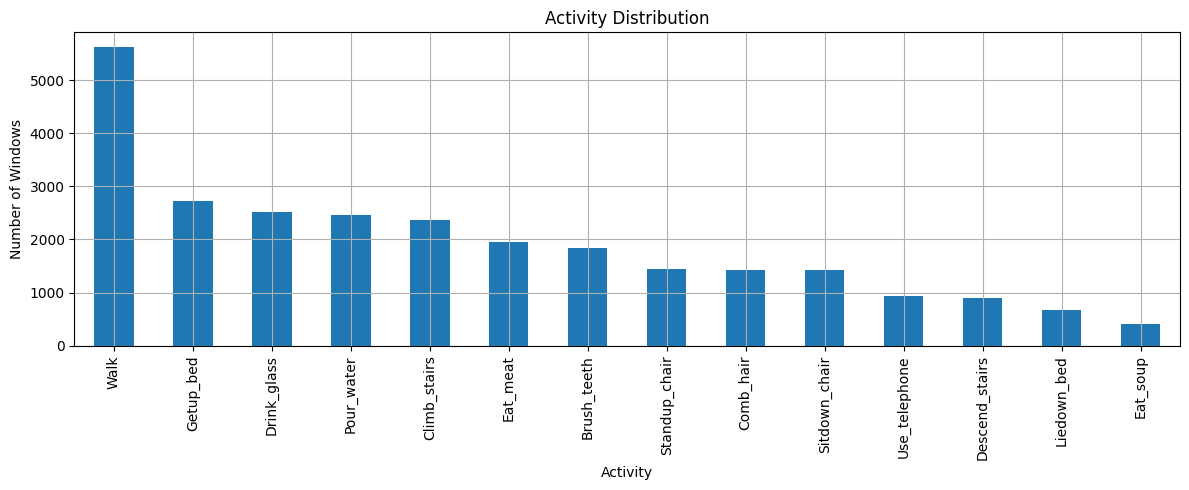

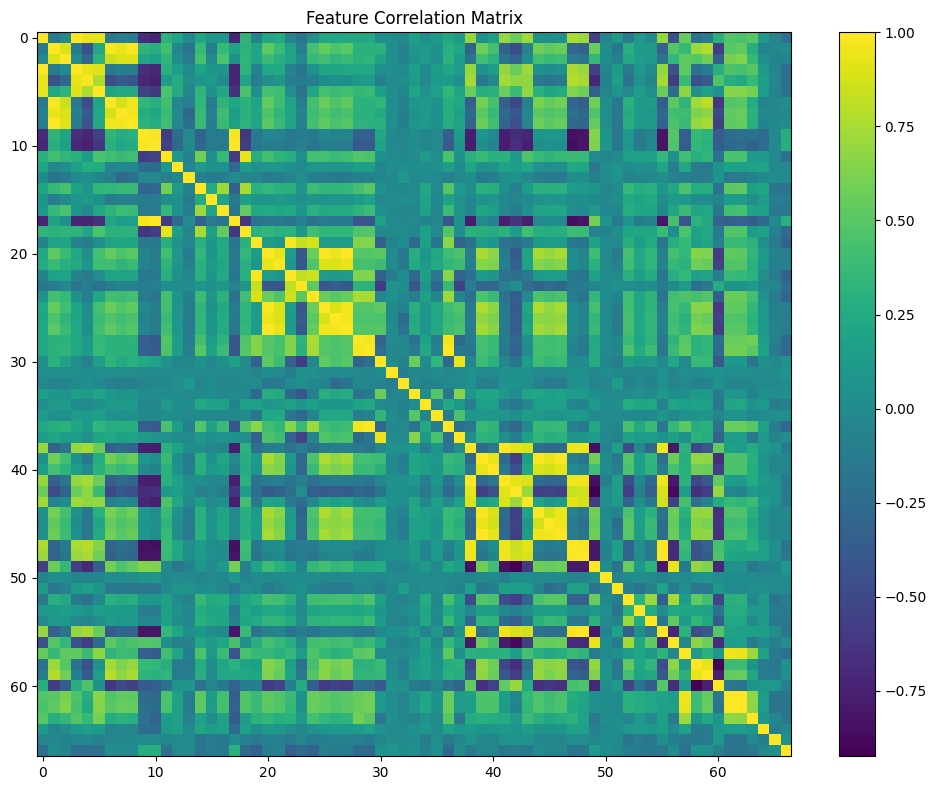


PART 5 COMPLETED


In [5]:
# ============================================================
# PART 5
# Final Dataset Preparation and Export
# ============================================================

print("="*80)
print("PART 5 : Final Dataset Preparation")
print("="*80)

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import matplotlib.pyplot as plt

# ============================================================
# Copy Dataset
# ============================================================

final_dataset = feature_dataset.copy()

# ============================================================
# Remove Duplicate Rows
# ============================================================

before_rows = len(final_dataset)

final_dataset.drop_duplicates(inplace=True)

after_rows = len(final_dataset)

print()
print("Duplicate Rows Removed :", before_rows - after_rows)

# ============================================================
# Replace Missing Values
# ============================================================

final_dataset.replace([np.inf,-np.inf],np.nan,inplace=True)
final_dataset.fillna(0,inplace=True)

print("Remaining Missing Values :",final_dataset.isnull().sum().sum())

# ============================================================
# Encode Activity Labels
# ============================================================

label_encoder = LabelEncoder()

final_dataset["Activity_Label"] = label_encoder.fit_transform(
    final_dataset["Activity"]
)

# Save Label Mapping
label_map = pd.DataFrame({
    "Activity":label_encoder.classes_,
    "Label":range(len(label_encoder.classes_))
})

label_map.to_csv(
    os.path.join(
        OUTPUT_FOLDER,
        "Activity_Label_Mapping.csv"
    ),
    index=False
)

# ============================================================
# Select Feature Columns
# ============================================================

metadata_columns = [
    "Activity",
    "Trial",
    "Window_ID",
    "Trial_Window",
    "Activity_Label"
]

feature_columns = [
    c for c in final_dataset.columns
    if c not in metadata_columns
]

print()
print("Number of Features :",len(feature_columns))

# ============================================================
# Normalize Features (Optional)
# ============================================================

NORMALIZE = True

if NORMALIZE:

    scaler = MinMaxScaler()

    final_dataset[feature_columns] = scaler.fit_transform(
        final_dataset[feature_columns]
    )

    print("Feature Normalization : Enabled")

else:

    print("Feature Normalization : Disabled")

# ============================================================
# Save Final Dataset
# ============================================================

csv_path = os.path.join(
    OUTPUT_FOLDER,
    "ADL_Final.csv"
)

xlsx_path = os.path.join(
    OUTPUT_FOLDER,
    "ADL_Final.xlsx"
)

final_dataset.to_csv(csv_path,index=False)
final_dataset.to_excel(xlsx_path,index=False)

print()
print("CSV Saved :",csv_path)
print("Excel Saved :",xlsx_path)

# ============================================================
# Dataset Summary
# ============================================================

print()
print("="*80)
print("FINAL DATASET SUMMARY")
print("="*80)

print("Rows :",final_dataset.shape[0])
print("Columns :",final_dataset.shape[1])

print("Activities :",final_dataset["Activity"].nunique())

print("Total Features :",len(feature_columns))

print()

print(final_dataset.head())

# ============================================================
# Activity Distribution
# ============================================================

activity_count = final_dataset["Activity"].value_counts()

print()
print("="*80)
print("Activity Distribution")
print("="*80)

print(activity_count)

activity_count.to_csv(
    os.path.join(
        OUTPUT_FOLDER,
        "Activity_Distribution.csv"
    )
)

# ============================================================
# Plot Activity Distribution
# ============================================================

plt.figure(figsize=(12,5))

activity_count.plot(kind="bar")

plt.title("Activity Distribution")

plt.xlabel("Activity")

plt.ylabel("Number of Windows")

plt.grid(True)

plt.tight_layout()

plt.show()

# ============================================================
# Correlation Matrix
# ============================================================

numeric_features = final_dataset[feature_columns]

corr = numeric_features.corr()

plt.figure(figsize=(10,8))

plt.imshow(corr,cmap="viridis",aspect="auto")

plt.colorbar()

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.show()

# ============================================================
# Save Feature Names
# ============================================================

feature_names = pd.DataFrame({
    "Feature_Name":feature_columns
})

feature_names.to_csv(
    os.path.join(
        OUTPUT_FOLDER,
        "Feature_List.csv"
    ),
    index=False
)

# ============================================================
# Save Metadata Separately
# ============================================================

metadata = final_dataset[
    [
        "Activity",
        "Activity_Label",
        "Trial",
        "Window_ID",
        "Trial_Window"
    ]
]

metadata.to_csv(
    os.path.join(
        OUTPUT_FOLDER,
        "Metadata.csv"
    ),
    index=False
)

print()

print("="*80)
print("PART 5 COMPLETED")
print("="*80)

In [10]:
# ============================================================
# PART 6
# Final Preprocessed Dataset Generation
# ============================================================

print("="*80)
print("PART 6 : FINAL PREPROCESSED DATASET")
print("="*80)

import os
import numpy as np
import pandas as pd

from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# COPY DATASET
# ============================================================

dataset = final_dataset.copy()

print("\nOriginal Dataset Shape :", dataset.shape)

# ============================================================
# REMOVE DUPLICATES
# ============================================================

before = dataset.shape[0]

dataset.drop_duplicates(inplace=True)

after = dataset.shape[0]

print("Duplicate Rows Removed :", before-after)

# ============================================================
# REMOVE MISSING VALUES
# ============================================================

dataset.replace([np.inf,-np.inf],np.nan,inplace=True)

dataset.fillna(0,inplace=True)

print("Missing Values :",dataset.isnull().sum().sum())

# ============================================================
# REMOVE METADATA
# ============================================================

metadata_columns = [
    "Trial",
    "Window_ID",
    "Trial_Window",
    "Activity_Label"
]

for col in metadata_columns:

    if col in dataset.columns:

        dataset.drop(columns=col,inplace=True)

# ============================================================
# SEPARATE LABEL
# ============================================================

labels = dataset["Activity"]

features = dataset.drop(columns=["Activity"])

print("\nOriginal Feature Count :",features.shape[1])

# ============================================================
# REMOVE CONSTANT FEATURES
# ============================================================

constant_cols = []

for col in features.columns:

    if features[col].nunique() <= 1:

        constant_cols.append(col)

features.drop(columns=constant_cols,
              inplace=True,
              errors='ignore')

print("Constant Features Removed :",len(constant_cols))

# ============================================================
# REMOVE LOW VARIANCE FEATURES
# ============================================================

selector = VarianceThreshold(
    threshold=1e-5
)

features_selected = selector.fit_transform(features)

selected_columns = features.columns[selector.get_support()]

features = pd.DataFrame(
    features_selected,
    columns=selected_columns
)

print("Remaining Features :",features.shape[1])

# ============================================================
# REMOVE HIGHLY CORRELATED FEATURES
# ============================================================

corr_matrix = features.corr().abs()

upper = corr_matrix.where(

    np.triu(np.ones(corr_matrix.shape),k=1).astype(bool)

)

drop_columns = [

    column

    for column in upper.columns

    if any(upper[column] > 0.95)

]

features.drop(columns=drop_columns,
              inplace=True)

print("Highly Correlated Features Removed :",len(drop_columns))

print("Final Feature Count :",features.shape[1])

# ============================================================
# NORMALIZATION
# ============================================================

NORMALIZE = True

if NORMALIZE:

    scaler = MinMaxScaler()

    features = pd.DataFrame(

        scaler.fit_transform(features),

        columns=features.columns

    )

    print("Normalization : Done")

# ============================================================
# CREATE FINAL DATASET
# ============================================================

final_preprocessed = features.copy()

# Activity should be LAST COLUMN

final_preprocessed["Activity"] = labels.values

# ============================================================
# CREATE CLUSTERING DATASET
# ============================================================

clustering_dataset = features.copy()

# ============================================================
# CREATE LABEL DATASET
# ============================================================

label_dataset = pd.DataFrame()

label_dataset["Activity"] = labels.values

# ============================================================
# SAVE FILES
# ============================================================

final_csv = os.path.join(
    OUTPUT_FOLDER,
    "ADL_Final.csv"
)

cluster_csv = os.path.join(
    OUTPUT_FOLDER,
    "ADL_Clustering.csv"
)

label_csv = os.path.join(
    OUTPUT_FOLDER,
    "ADL_Labels.csv"
)

final_excel = os.path.join(
    OUTPUT_FOLDER,
    "ADL_Final.xlsx"
)

final_preprocessed.to_csv(
    final_csv,
    index=False
)

final_preprocessed.to_excel(
    final_excel,
    index=False
)

clustering_dataset.to_csv(
    cluster_csv,
    index=False
)

label_dataset.to_csv(
    label_csv,
    index=False
)

# ============================================================
# SAVE FEATURE LIST
# ============================================================

pd.DataFrame({

    "Feature_Name":features.columns

}).to_csv(

    os.path.join(
        OUTPUT_FOLDER,
        "Selected_Features.csv"
    ),

    index=False

)

# ============================================================
# SAVE CORRELATION MATRIX
# ============================================================

features.corr().to_csv(

    os.path.join(
        OUTPUT_FOLDER,
        "Correlation_Matrix.csv"
    )

)

# ============================================================
# DATASET SUMMARY
# ============================================================

summary = pd.DataFrame({

    "Metric":[

        "Activities",

        "Samples",

        "Original Features",

        "Selected Features"

    ],

    "Value":[

        labels.nunique(),

        len(final_preprocessed),

        feature_dataset.shape[1]-4,

        features.shape[1]

    ]

})

summary.to_csv(

    os.path.join(
        OUTPUT_FOLDER,
        "Dataset_Summary.csv"
    ),

    index=False

)

# ============================================================
# PRINT SUMMARY
# ============================================================

print("\n"+"="*80)

print("FINAL DATASET SUMMARY")

print("="*80)

print("Activities           :",labels.nunique())

print("Samples              :",len(final_preprocessed))

print("Selected Features    :",features.shape[1])

print("Final Dataset Shape  :",final_preprocessed.shape)

print("Clustering Shape     :",clustering_dataset.shape)

print("="*80)

print("\nFiles Saved")

print("- ADL_Final.csv")

print("- ADL_Final.xlsx")

print("- ADL_Clustering.csv")

print("- ADL_Labels.csv")

print("- Selected_Features.csv")

print("- Correlation_Matrix.csv")

print("- Dataset_Summary.csv")

print("="*80)

print("PART 6 COMPLETED")

print("="*80)

PART 6 : FINAL PREPROCESSED DATASET

Original Dataset Shape : (26663, 72)
Duplicate Rows Removed : 0
Missing Values : 0

Original Feature Count : 67
Constant Features Removed : 0
Remaining Features : 67
Highly Correlated Features Removed : 18
Final Feature Count : 49
Normalization : Done

FINAL DATASET SUMMARY
Activities           : 14
Samples              : 26663
Selected Features    : 49
Final Dataset Shape  : (26663, 50)
Clustering Shape     : (26663, 49)

Files Saved
- ADL_Final.csv
- ADL_Final.xlsx
- ADL_Clustering.csv
- ADL_Labels.csv
- Selected_Features.csv
- Correlation_Matrix.csv
- Dataset_Summary.csv
PART 6 COMPLETED
